In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(291,495)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   
        
        
        
        
        
complexRef = mda.Universe("../complex/1/3_npt/protein_cluster_center_ff.gro")
hivseq = complexRef.select_atoms("resid 1:231").residues.resnames[:231]

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
all_contacts_2d = []
for i in range(5):
    all_contacts_2d.append(load("../complex/complexContacts_2d_trajectory"+str(i+1)+".npy"))
    
contacts_2d = mean(all_contacts_2d,axis = 0)

#contacts_2d=0
#for i in range(5):
#    contacts_2d+=load("../complex/complexContacts_2d_trajectory"+str(i+1)+".npy")/5

(74.0, 85.0)

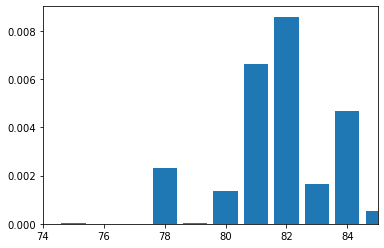

In [4]:
#contacts_2d[332-290].shape
nspry = 493-290 

contacts_by_CA=[]
for i in range(1,18+1):
    contacts_by_CA.append(contacts_2d[:nspry+1,1+nspry+(231*(i-1)):1+nspry+(231*(i))])

    
mean_332_contacts = mean(contacts_by_CA,axis = 0)[334-290]
bar(arange(len(mean_332_contacts)),mean_332_contacts)

xlim(74,85)

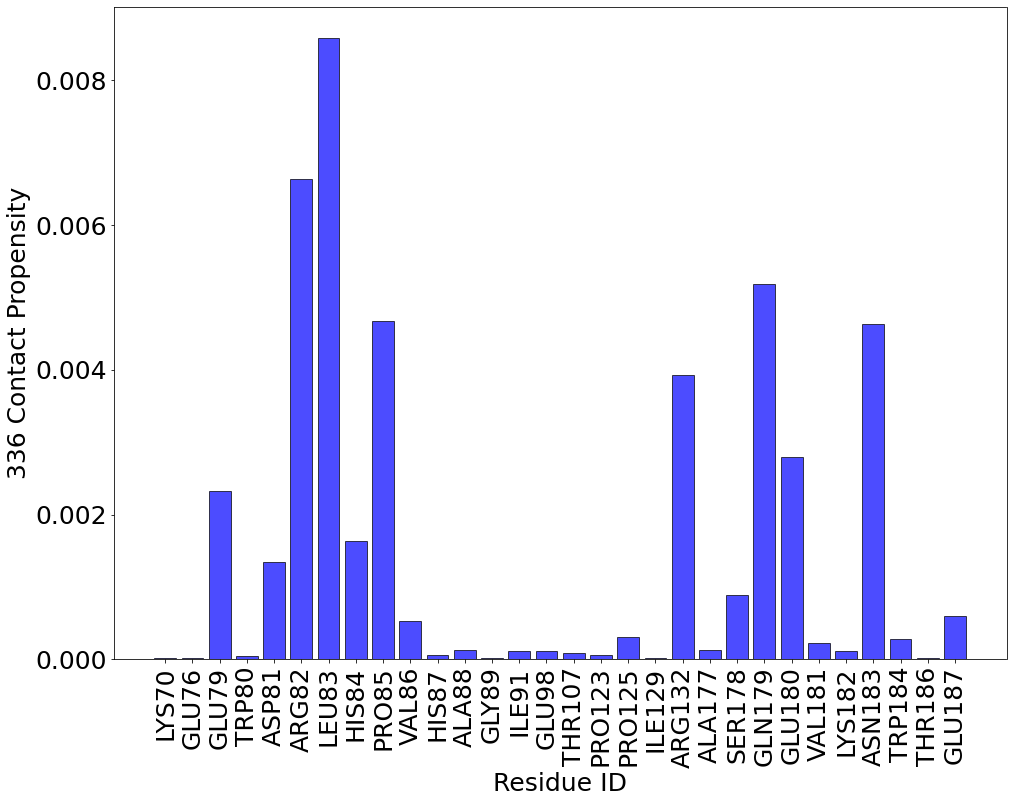

In [5]:
nonzero_indices=list(where(mean_332_contacts >0)[0])

all_nonzero_resids = []
all_nonzero_resids_ints=[]
all_nonzero_resids_andNames=[]
for i in range(len(nonzero_indices)):
    all_nonzero_resids.append(str(nonzero_indices[i]))
    all_nonzero_resids_andNames.append(hivseq[nonzero_indices[i]]+str(nonzero_indices[i]+1))

    all_nonzero_resids_ints.append((nonzero_indices[i]))


system_non_zero_propensities=mean_332_contacts[nonzero_indices]
#system_non_zero_sem=mean_332_contacts[all_nonzero_indices]
    
    
figure(figsize = (16,12))
bar(all_nonzero_resids_andNames,system_non_zero_propensities,alpha = .7,color = "blue",edgecolor = "black")

#errorbar(arange(len(all_nonzero_resids))-0.1,system_non_zero_propensities,system_non_zero_sem[0],fmt = ".",alpha = .99,color = colourScheme[0],linewidth = 3)


#legend(fontsize = 25)
xlabel("Residue ID",fontsize = 25)
ylabel("336 Contact Propensity",fontsize = 25)
sakdfjahsfk=xticks(fontsize = 25,rotation = 90)
akldsfhskfr=yticks(fontsize = 25)    
    

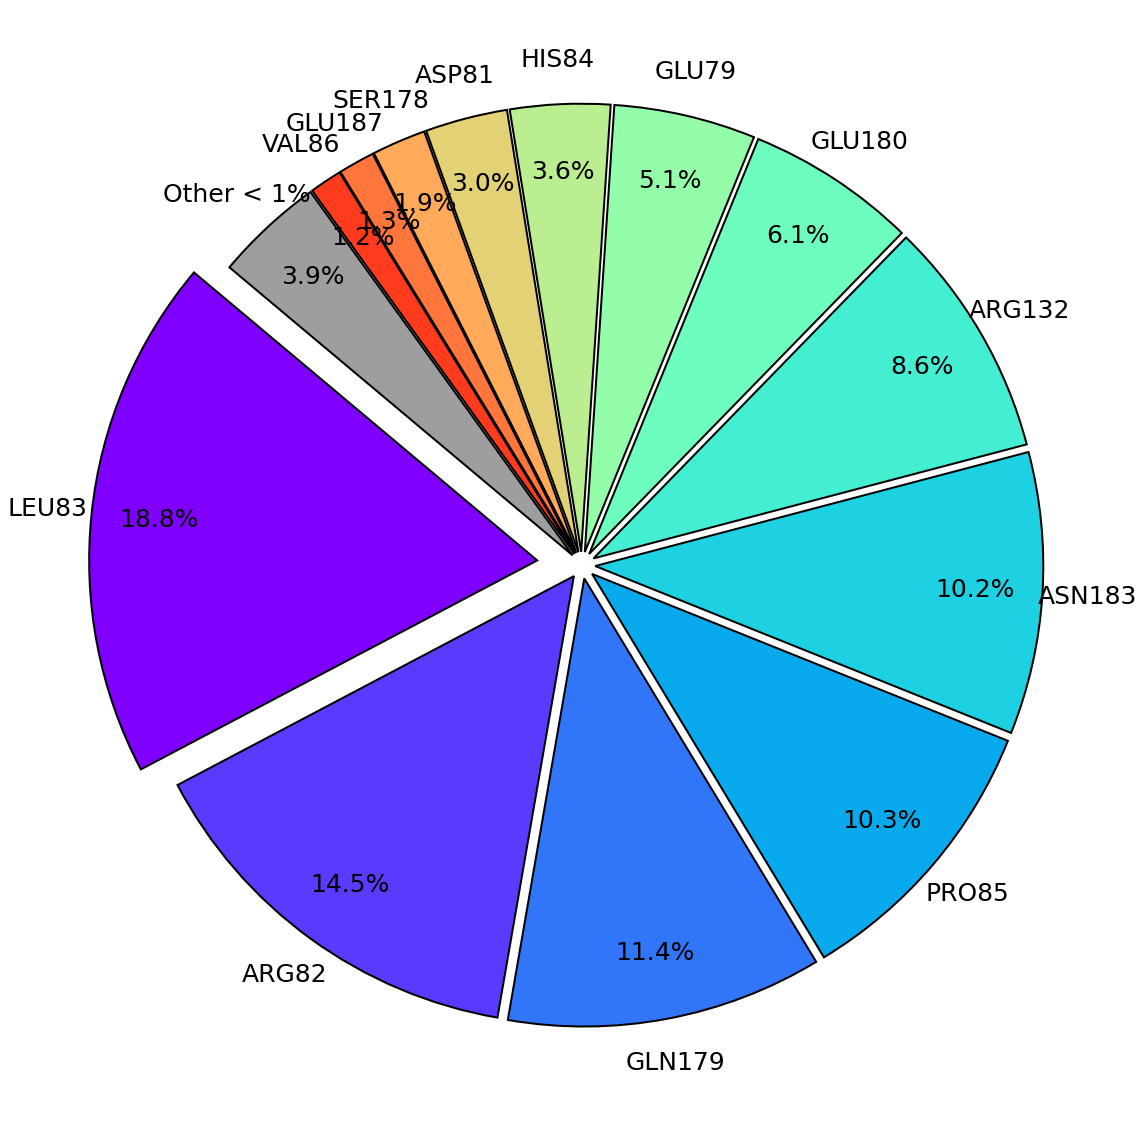

In [6]:
# Assuming system_non_zero_propensities and all_nonzero_resids_andNames are defined
sizes = system_non_zero_propensities / sum(system_non_zero_propensities) * 100
labels = all_nonzero_resids_andNames

# Sort sizes and labels based on sizes in descending order
sorted_indices = np.argsort(sizes)[::-1]
sorted_sizes = sizes[sorted_indices]
sorted_labels = [labels[i] for i in sorted_indices]

# Combine all slices < 3% into "Other < 3%"
threshold = 1  # Define the threshold percentage
other_size = sum([size for size in sorted_sizes if size < threshold])
filtered_sizes = [size for size in sorted_sizes if size >= threshold]
filtered_labels = [label for label, size in zip(sorted_labels, sorted_sizes) if size >= threshold]

# Add the "Other < 3%" category
if other_size > 0:
    filtered_sizes.append(other_size)
    filtered_labels.append("Other < 1%")

# Choose a color map, e.g., 'rainbow'
colors = plt.cm.rainbow(np.linspace(0, 1, len(filtered_sizes)))
colors[-1] = array([220,220,220,355])/355
# Define a function to scale explode values with better control
def controlled_explode(size, max_explode=0.1, min_explode=0):
    return max_explode * (1 - np.sqrt(size / 100)) + min_explode

# Apply the explode function to all remaining sizes
explode = [controlled_explode(size) for size in filtered_sizes]
explode = array(explode)*0+.03
explode[0] = .1
# Create the pie chart with enhancements
plt.figure(figsize=(16, 16))  # Increase the size of the figure
wedges, texts, autotexts = plt.pie(filtered_sizes, 
                                   labels=filtered_labels, 
                                   colors=colors, 
                                   autopct='%1.1f%%',  # Display percentages on the chart
                                   startangle=140,     # Start the chart at a different angle
                                   explode=explode,    # Explode based on controlled scaling
                                   wedgeprops={'edgecolor': 'black', 'linewidth': 2},  # Add borders to slices
                                   textprops={'fontsize': 25},  # Adjust label font size
                                   pctdistance=0.85)   # Position percentage text slightly outside

# Adjust label position
for text in texts:
    text.set_fontsize(25)
    text.set_horizontalalignment('center')

# Adjust the percentage text position and styling
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(25)

# Draw lines from labels to their corresponding slices
#plt.legend(wedges, filtered_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=25)

# Equal aspect ratio ensures the pie chart is circular
plt.axis('equal')  
#plt.title('Pie Chart with "Other < 3%" Category')
plt.tight_layout()
plt.show()

In [7]:
# POSSIBLE THAT THRE

(0.0, 205.0)

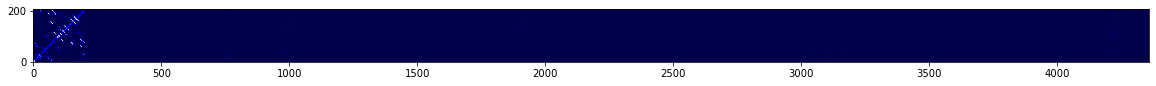

In [8]:
figure(figsize = (20,100))
imshow(contacts_2d,origin = "lower",cmap = "seismic")
ylim(0,205)

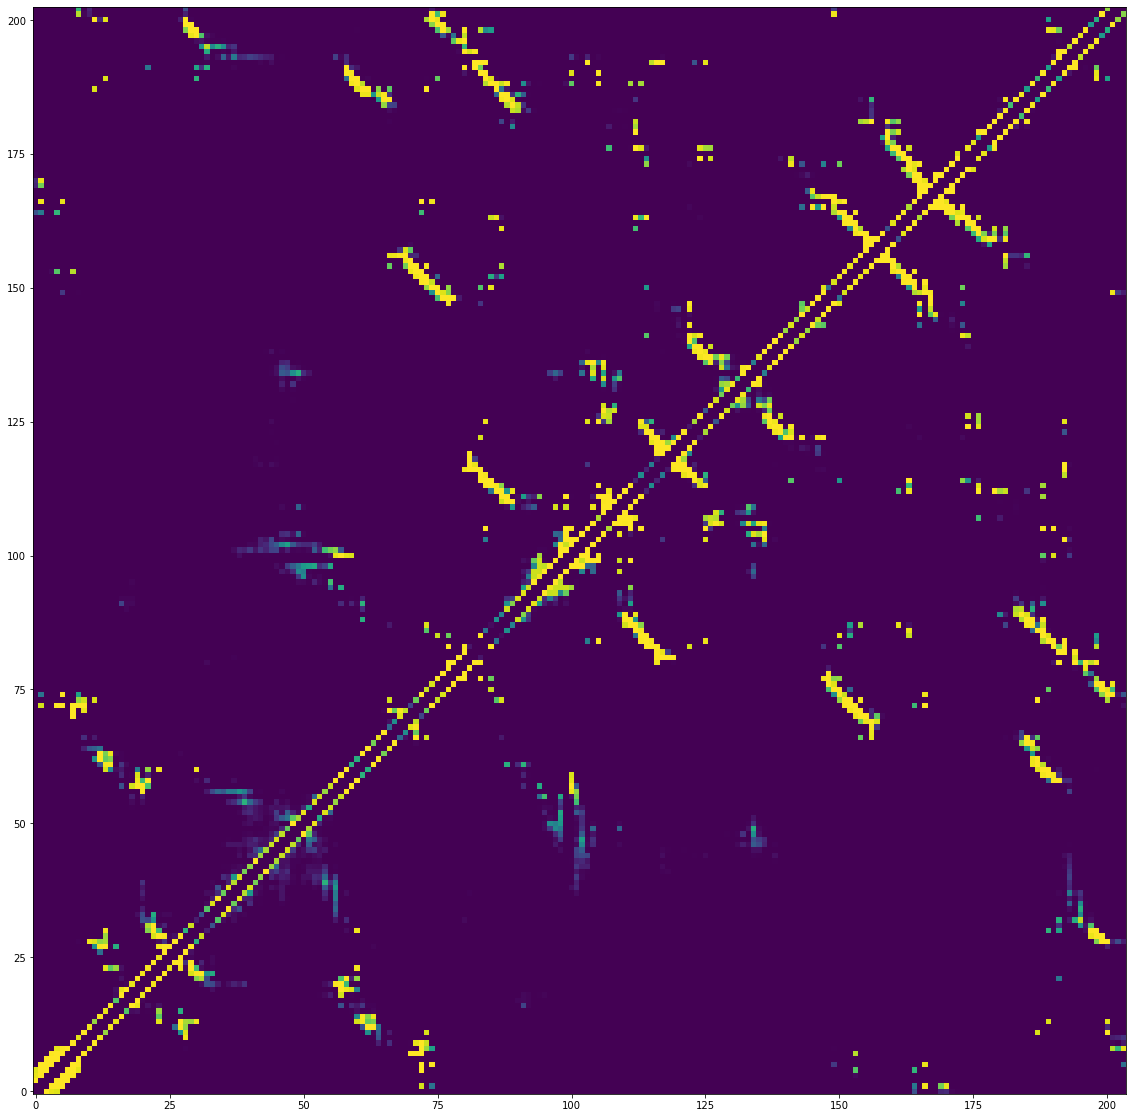

In [9]:
figure(figsize = (20,20))
imshow(contacts_2d[:493-290,:493-290+1],origin = "lower")

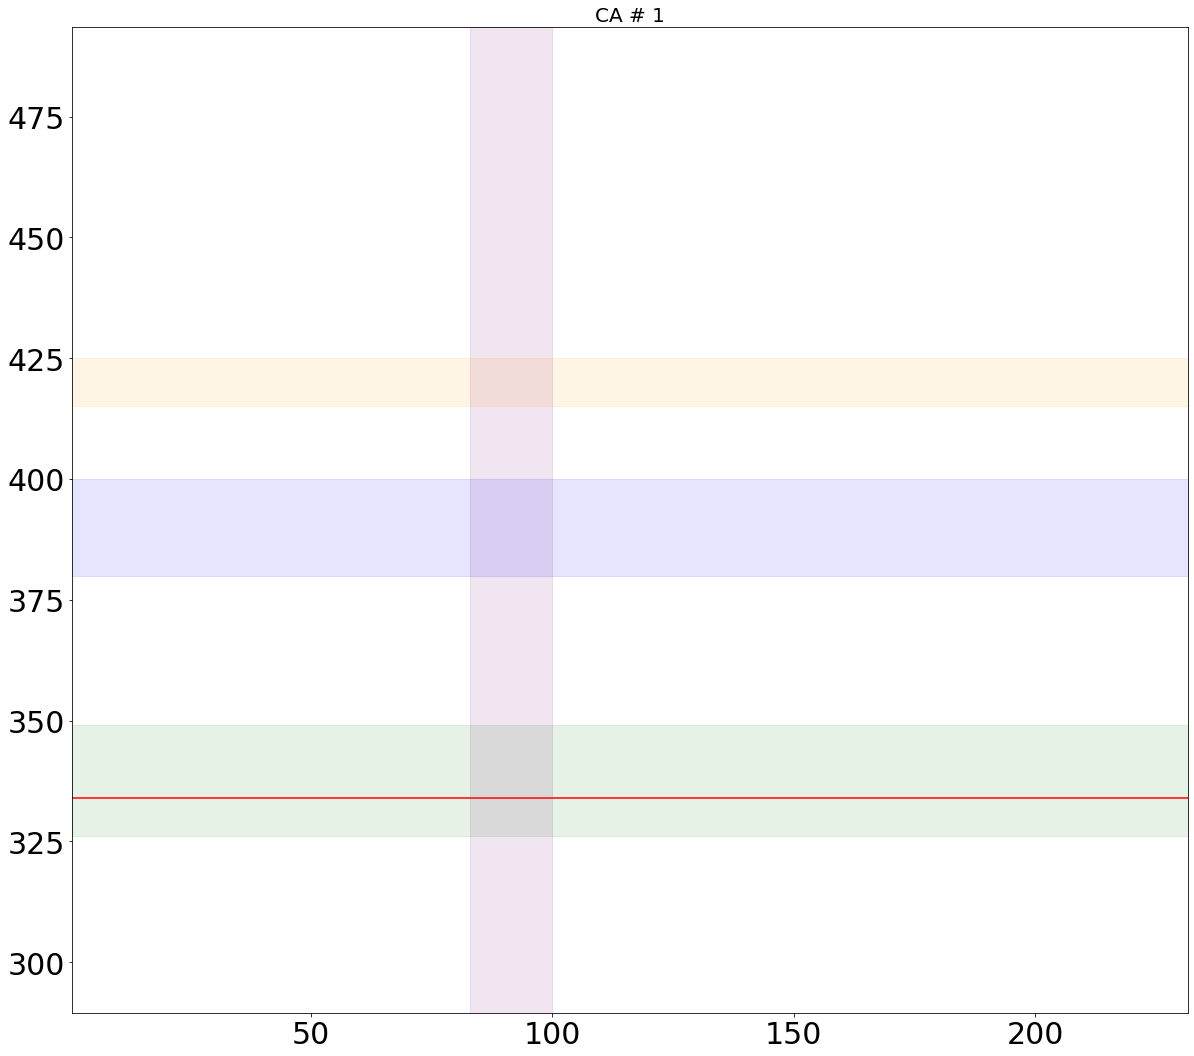

In [10]:
i=1
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


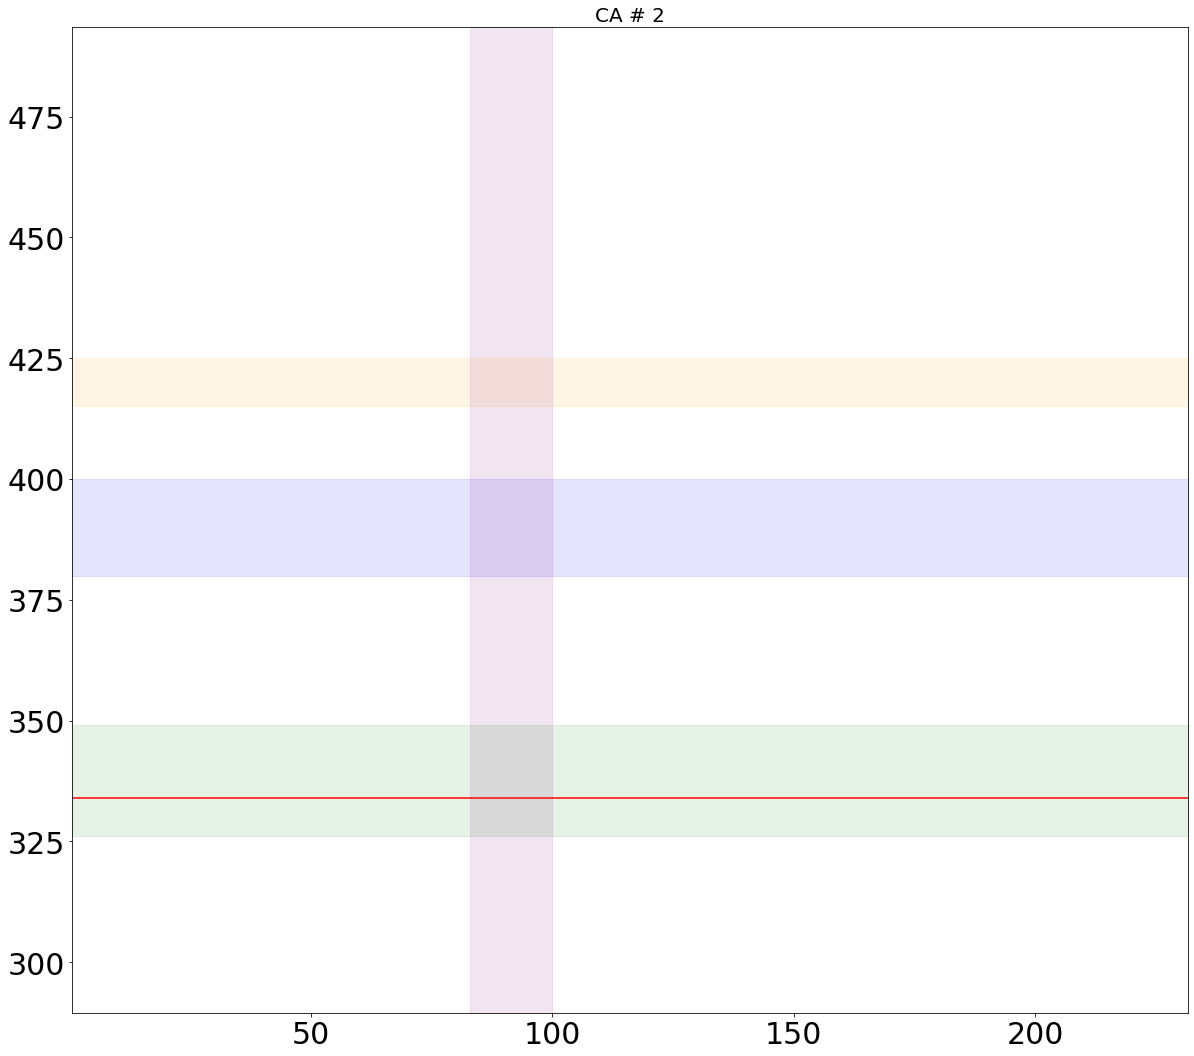

In [11]:
i=2
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)
#colorbar()
xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


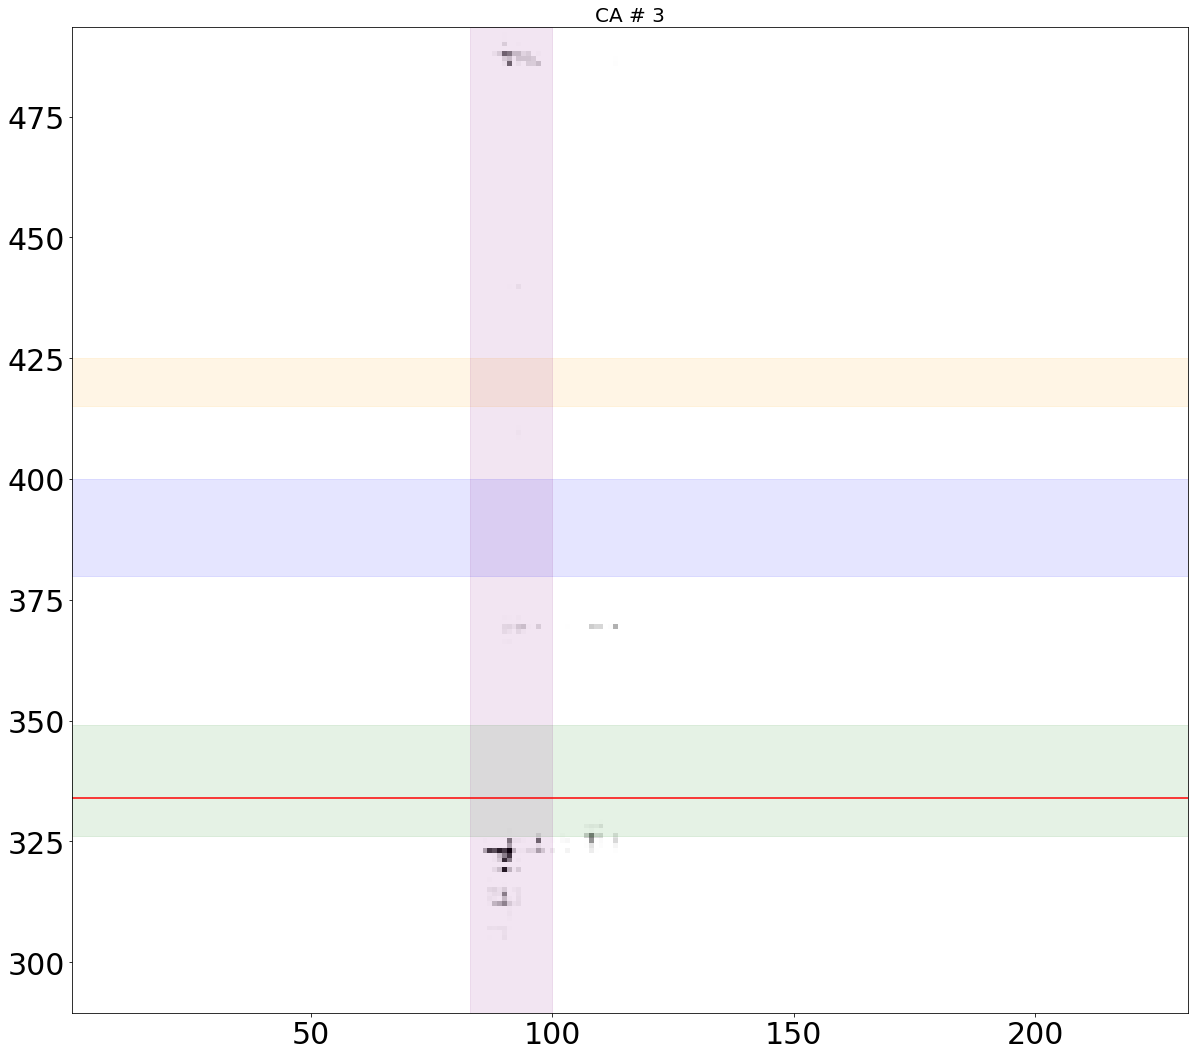

In [12]:
i=3
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)
axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


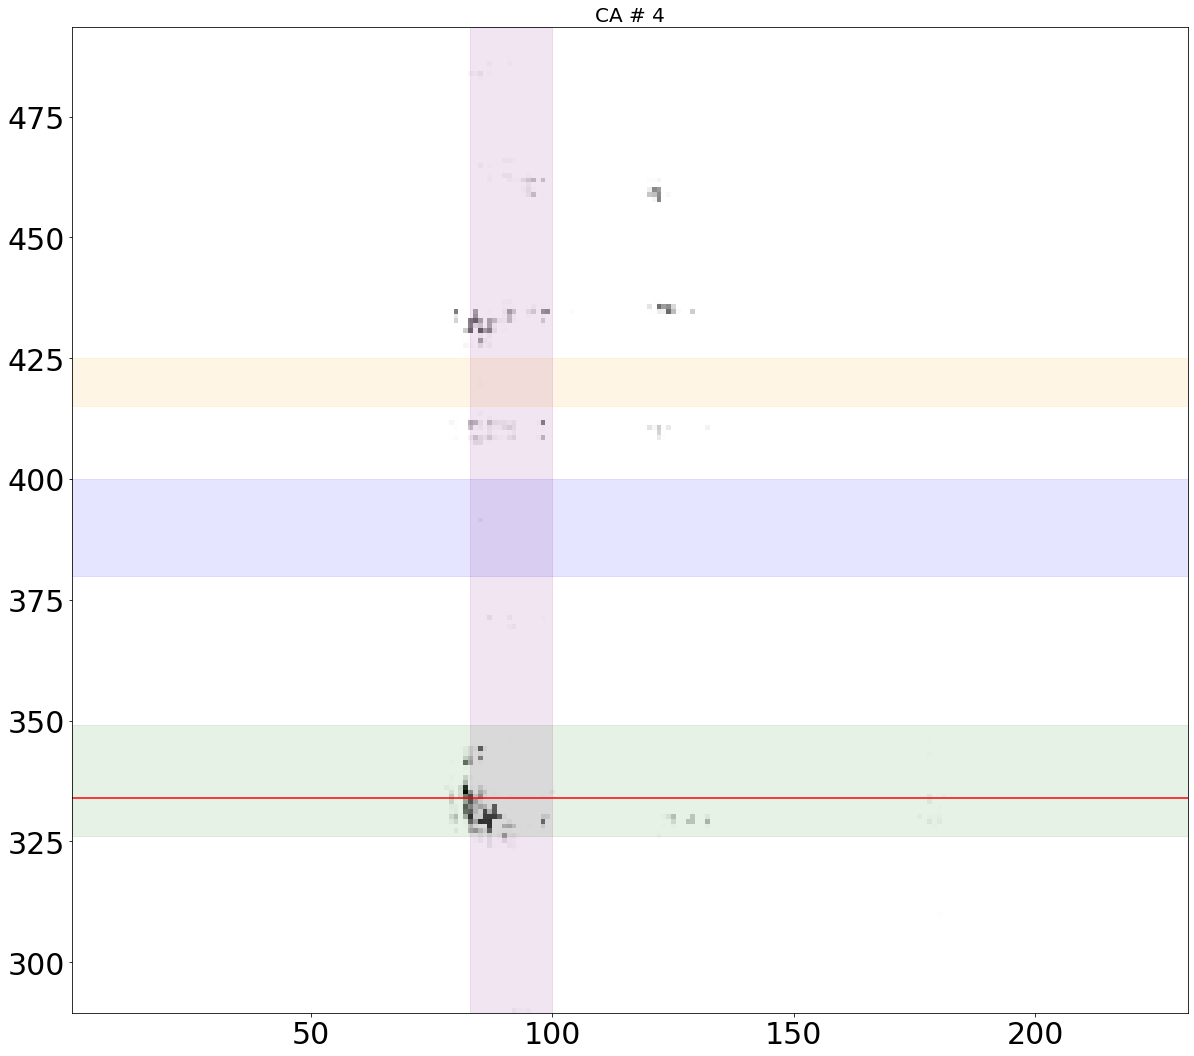

In [13]:
i=4
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)
axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


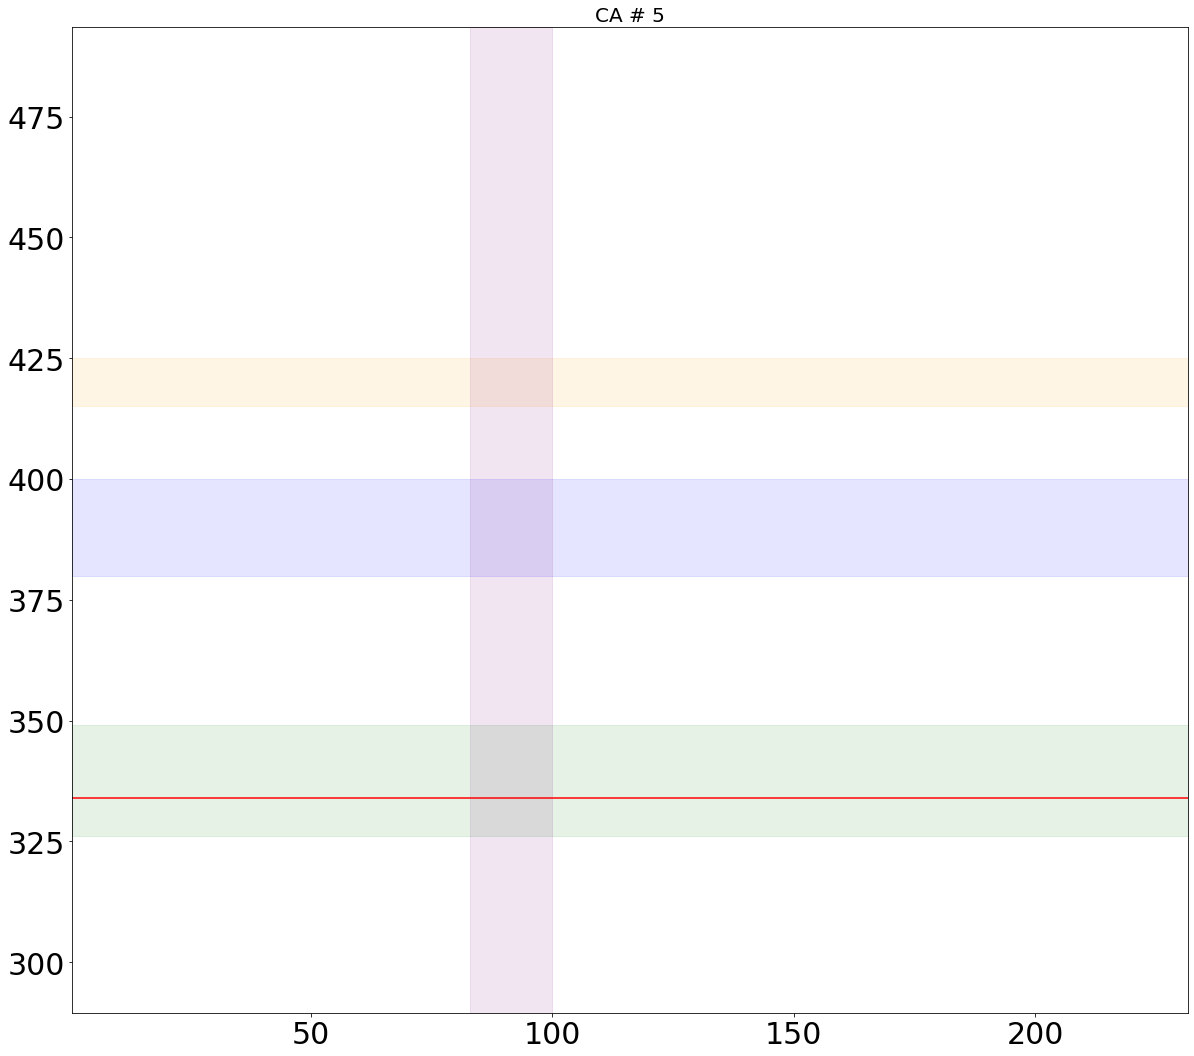

In [14]:
i=5
nspry = 494-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


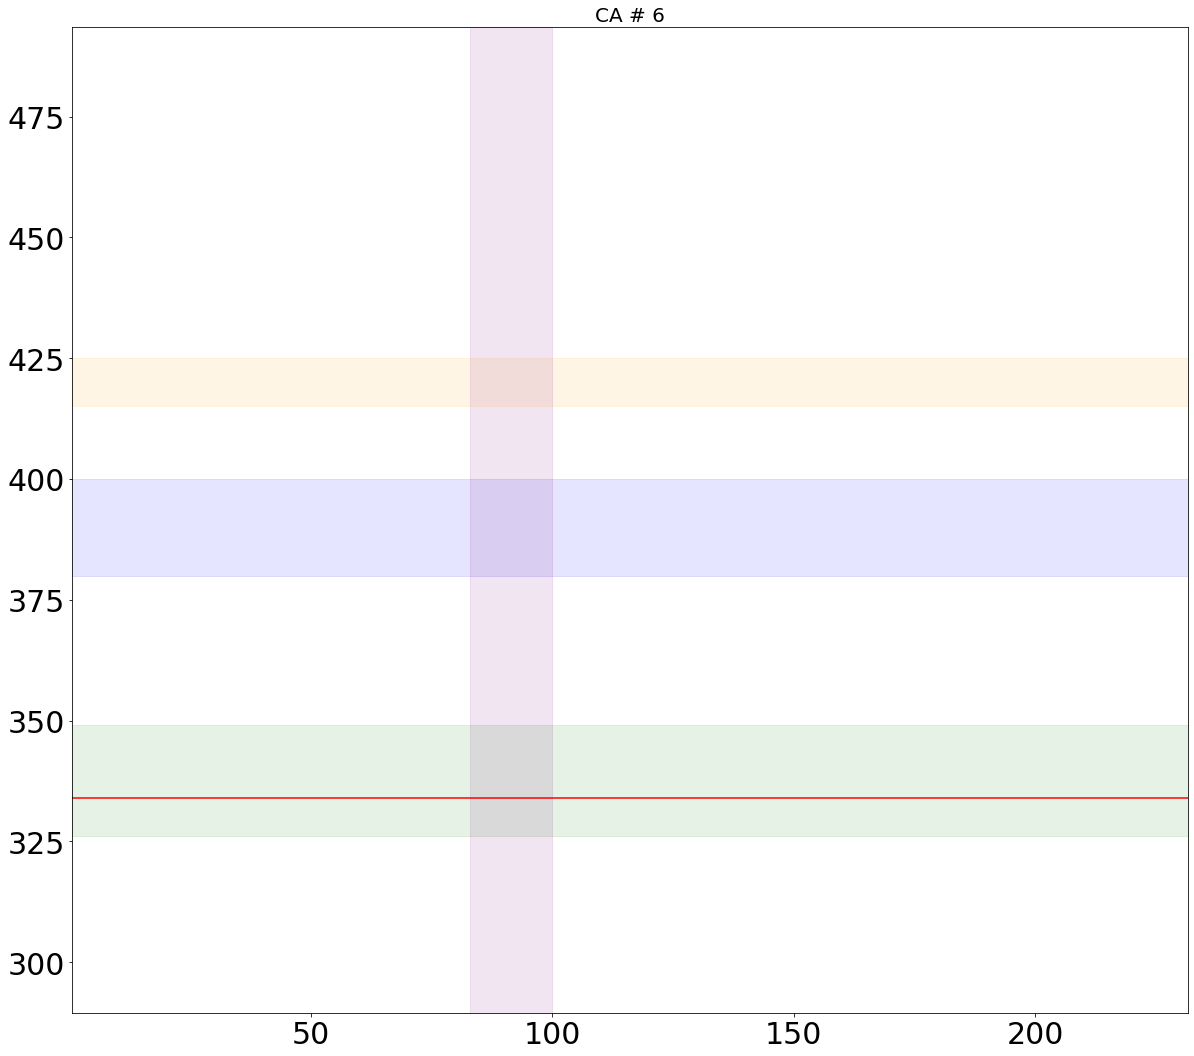

In [15]:
i=6
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


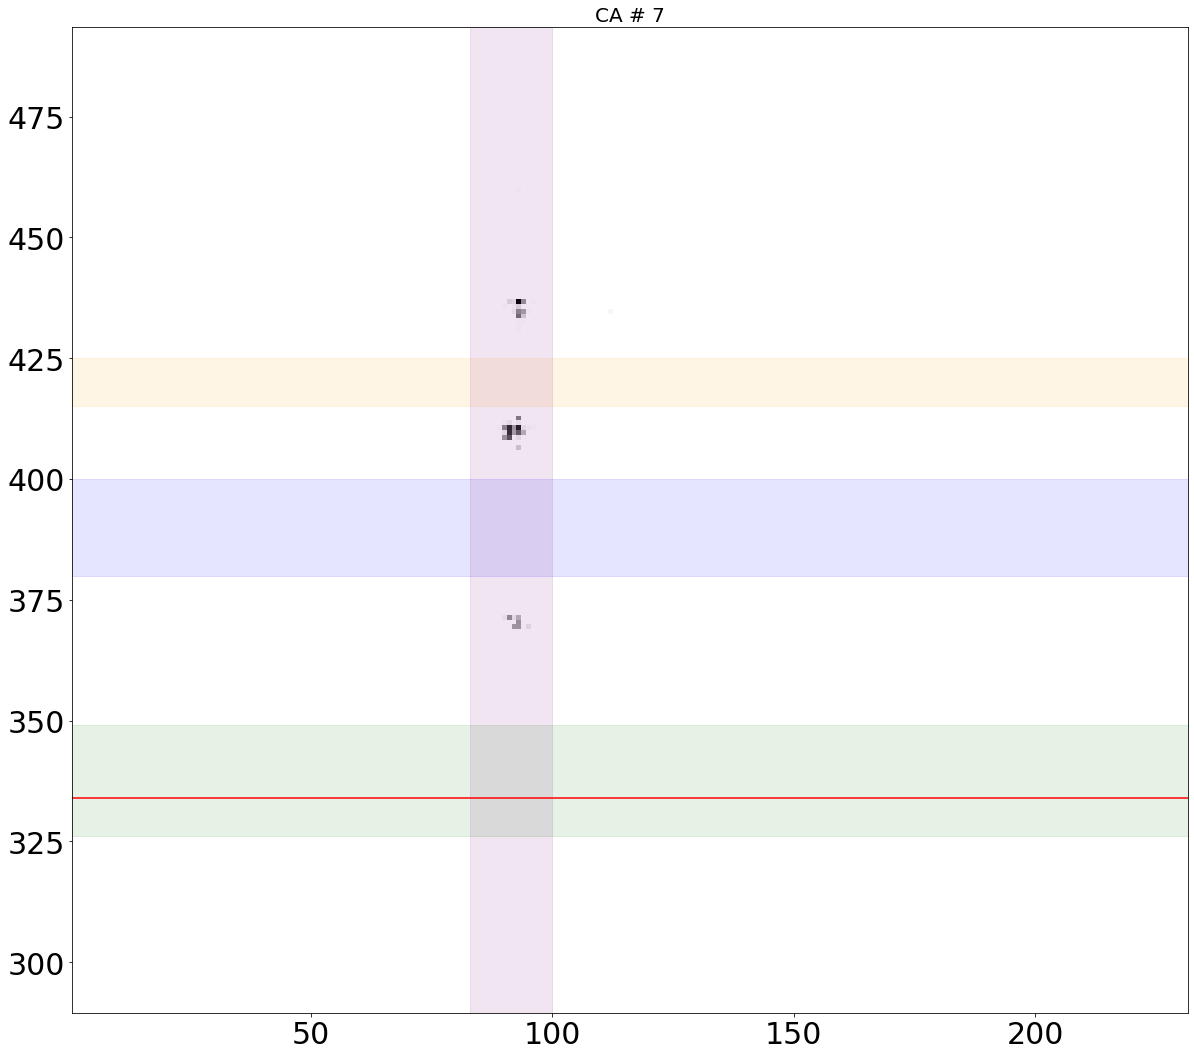

In [16]:
i=7
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")


axvspan(83,100,color = "purple",alpha = 0.1)


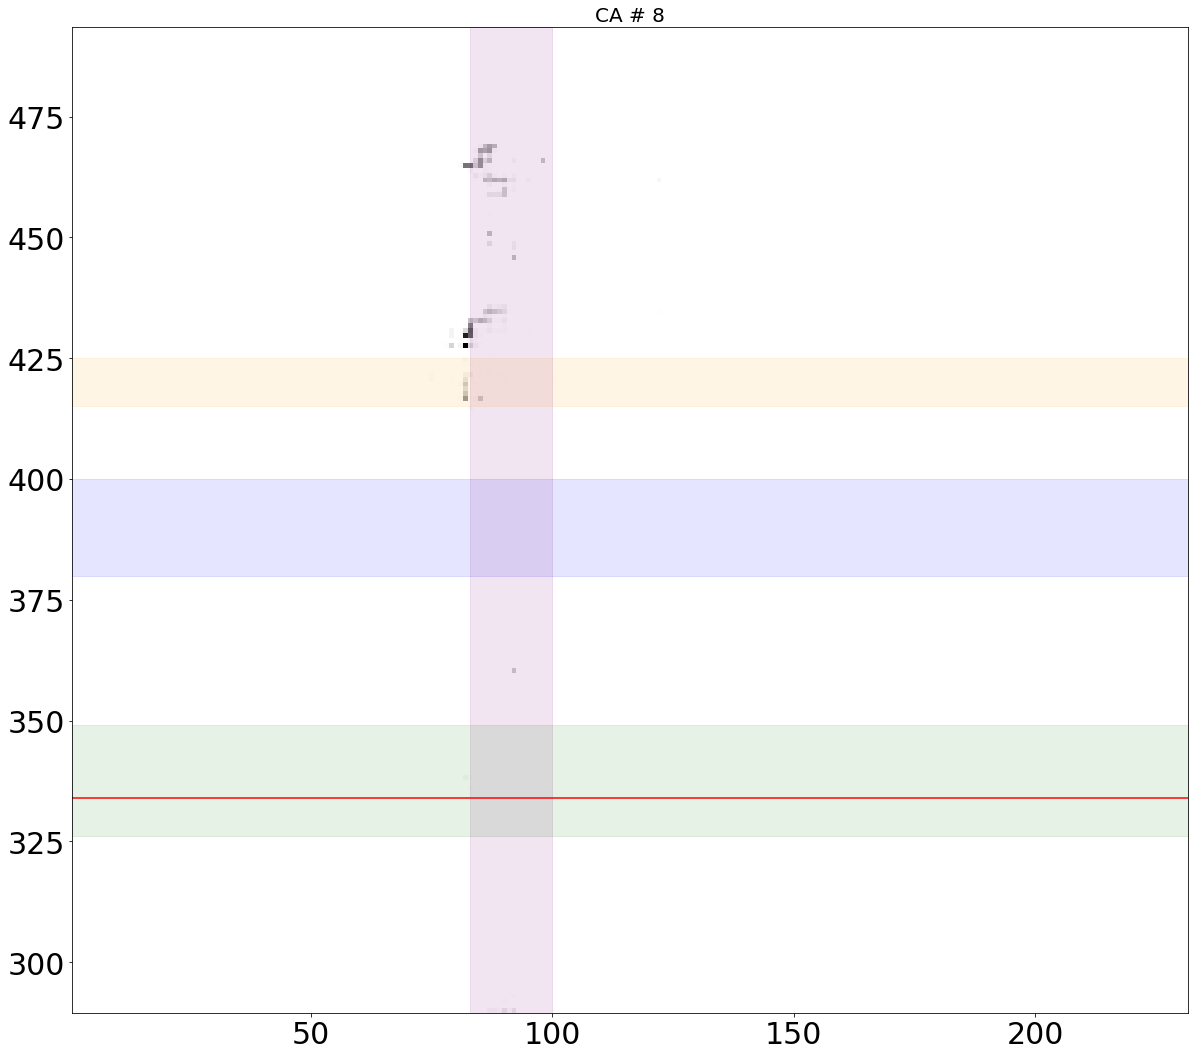

In [17]:
i=8
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


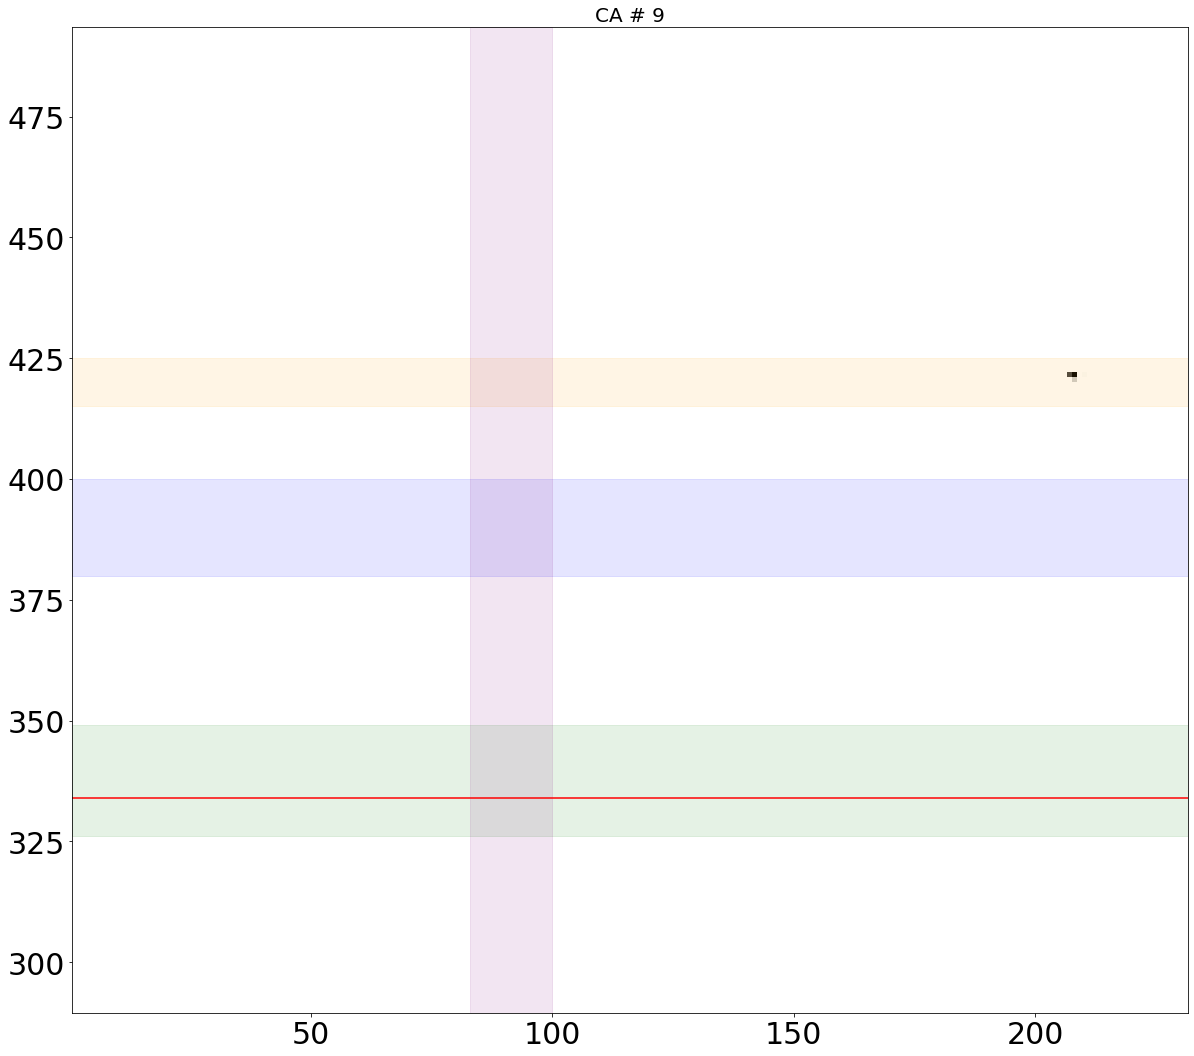

In [18]:
i=9
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


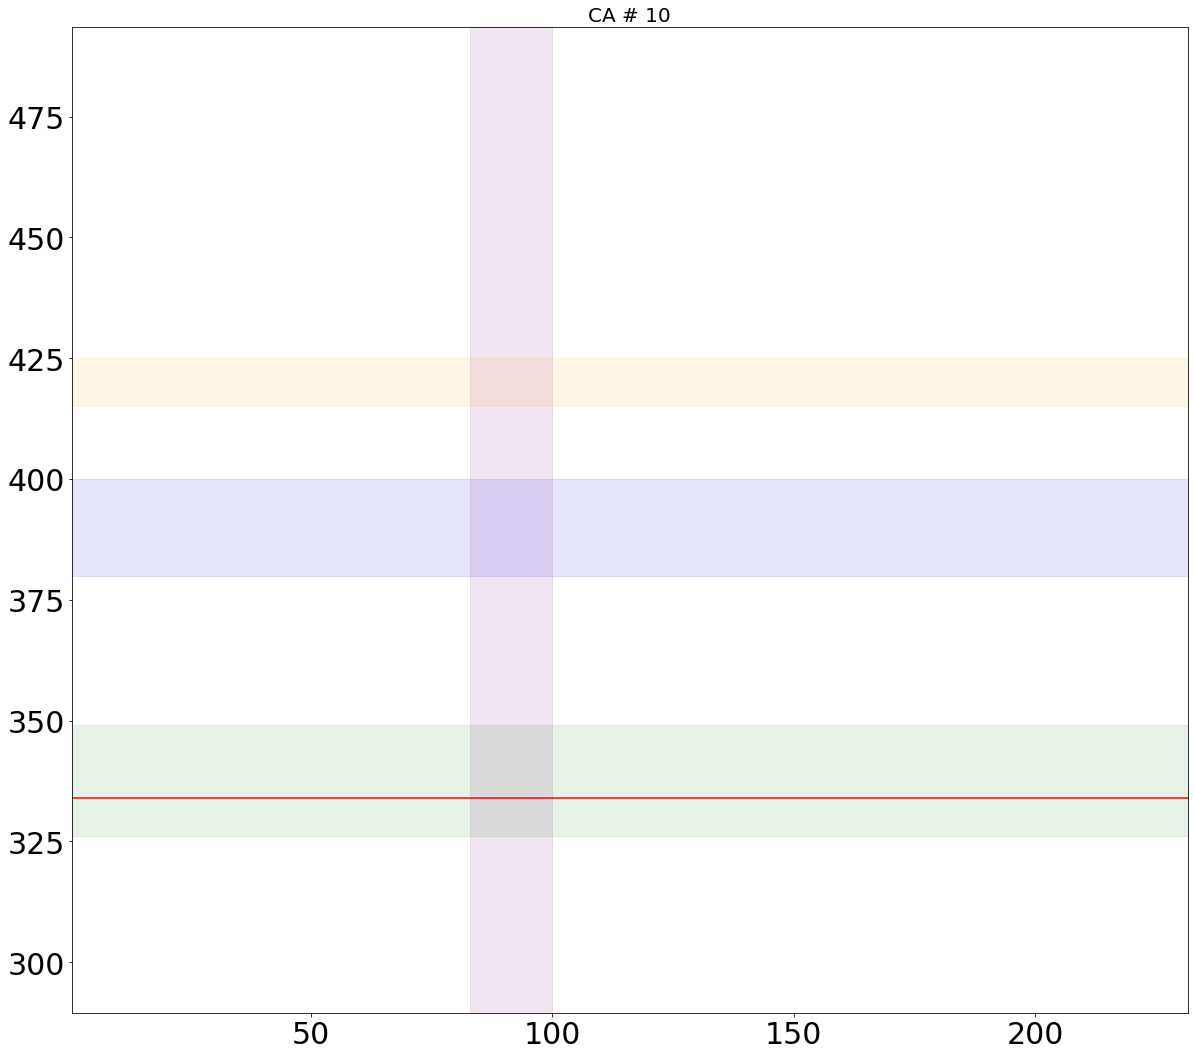

In [19]:
i=10
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


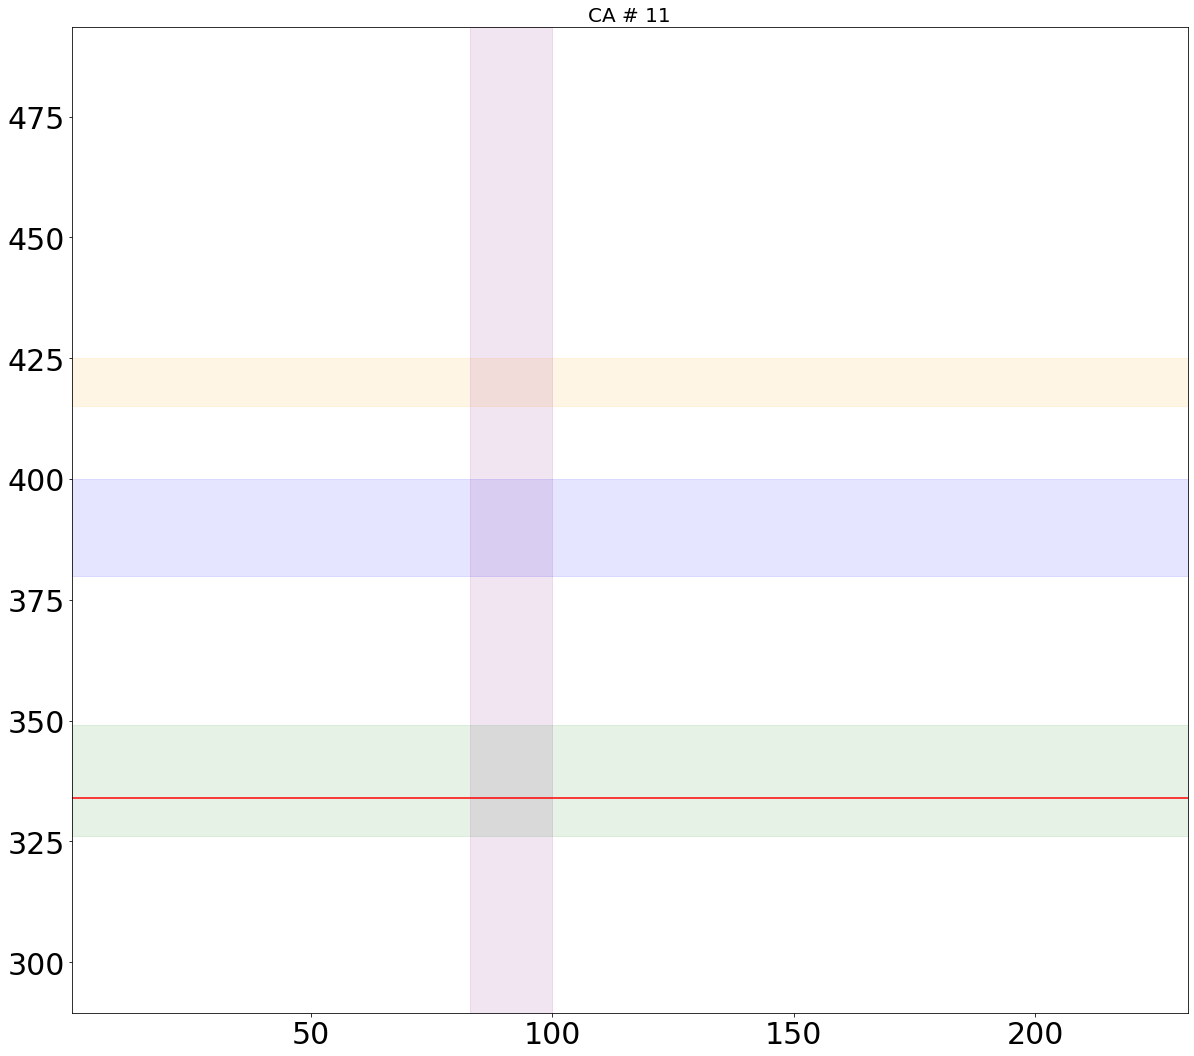

In [20]:
i=11
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


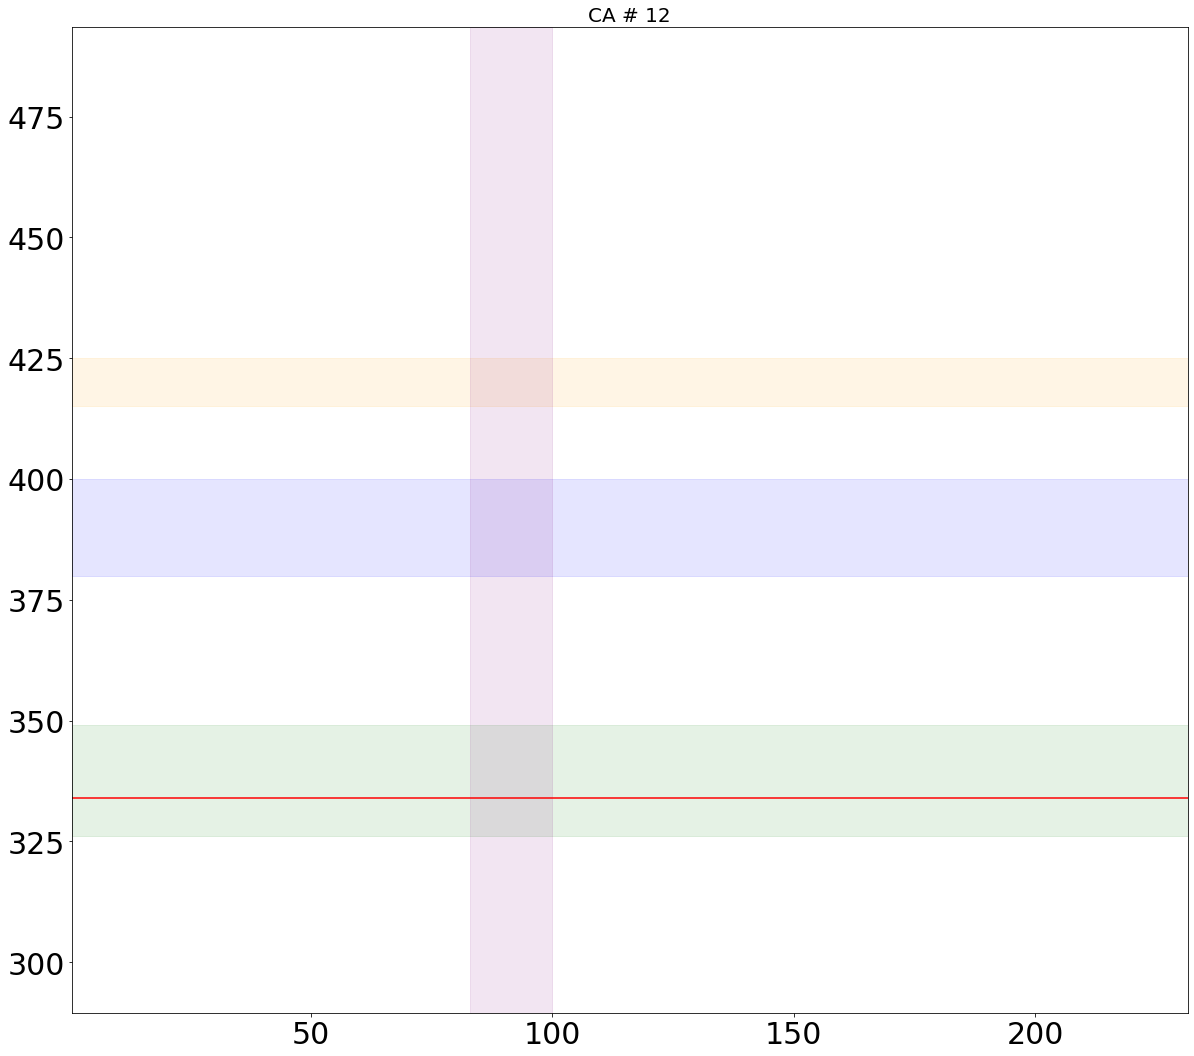

In [21]:
i=12
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


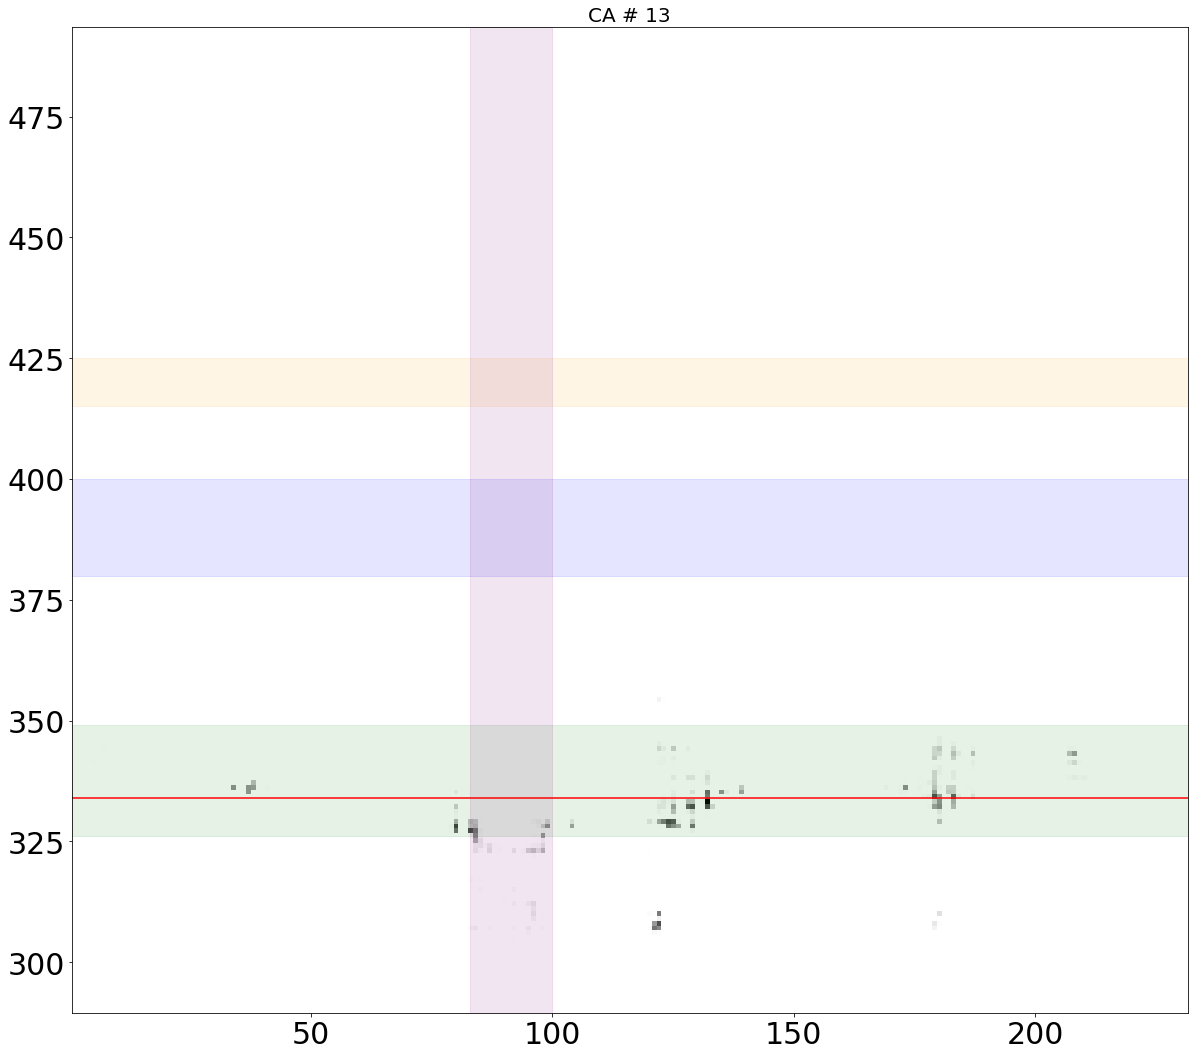

In [22]:
i=13
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


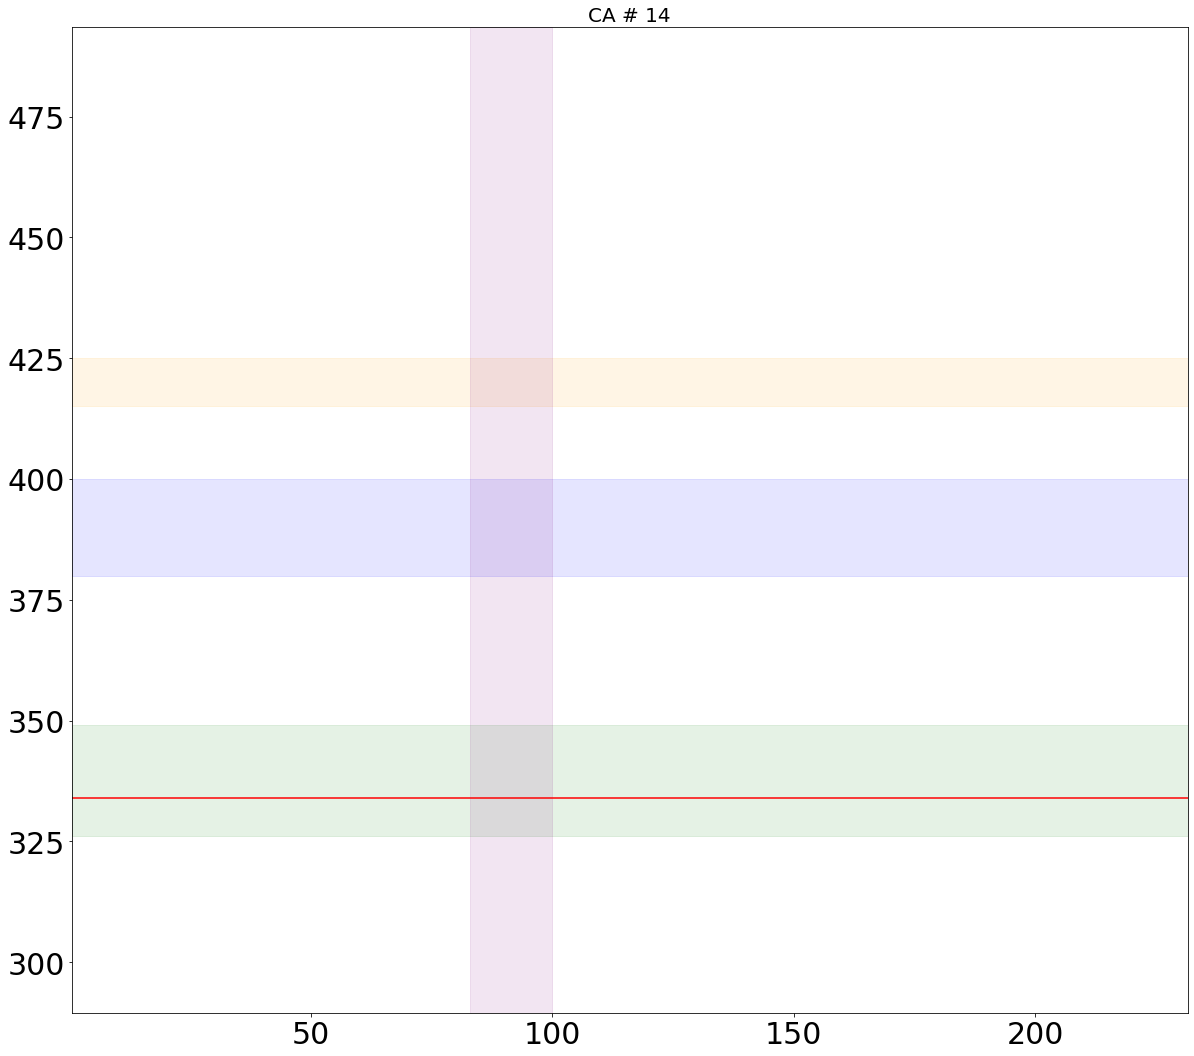

In [23]:
i=14
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


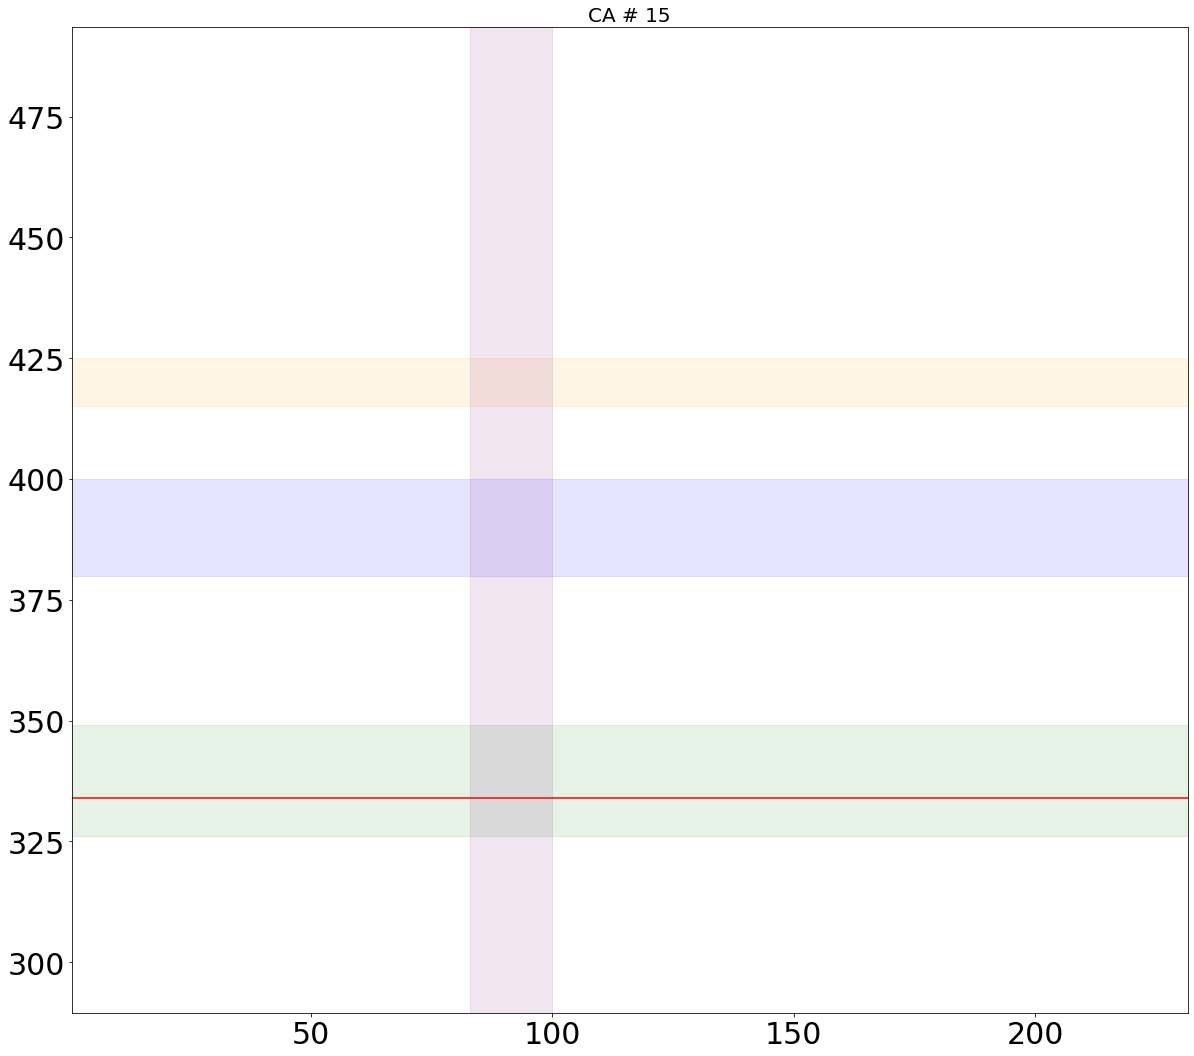

In [24]:
i=15
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


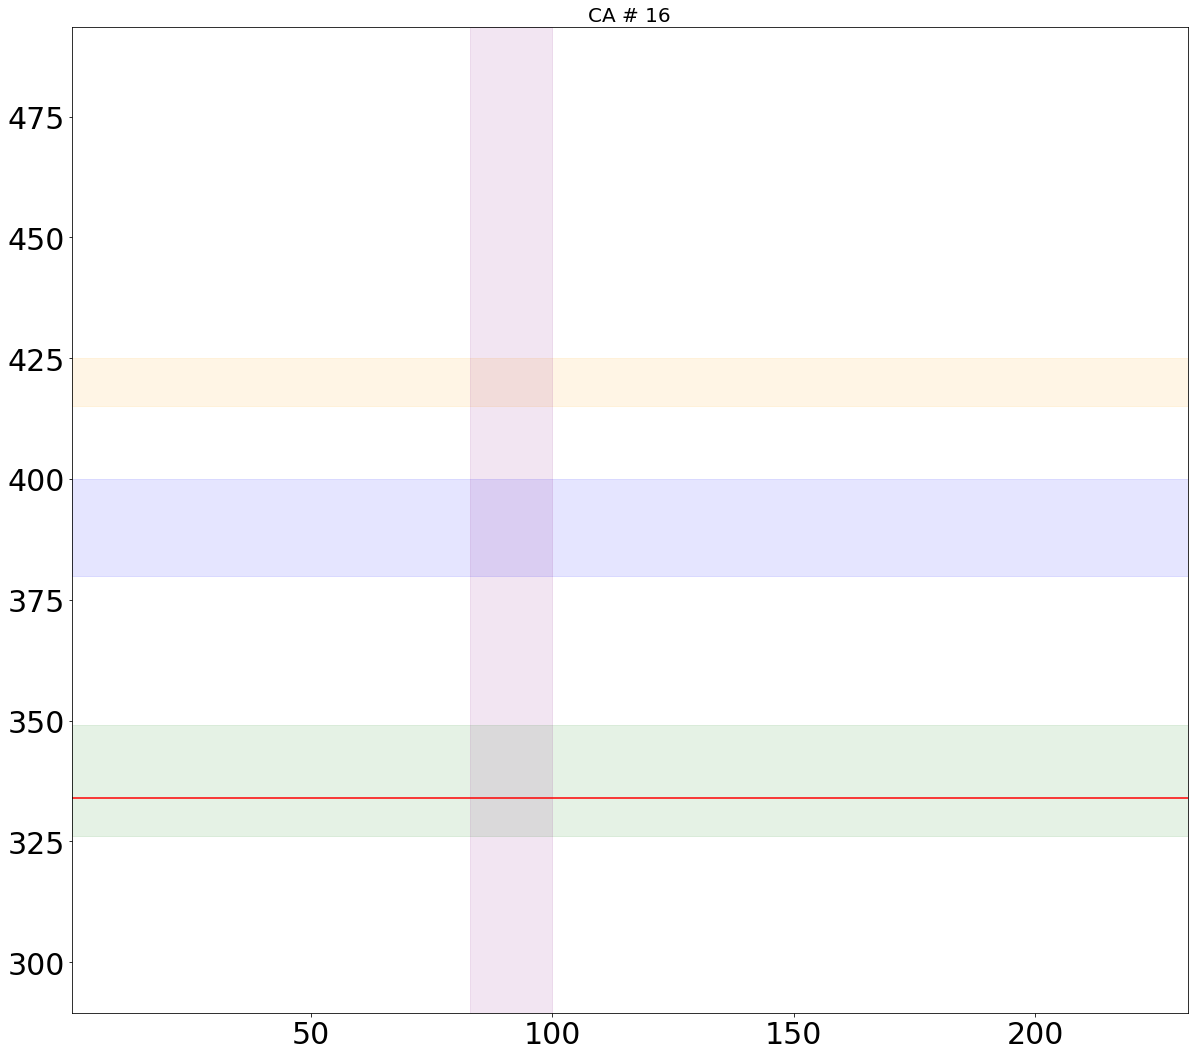

In [25]:
i=16
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)


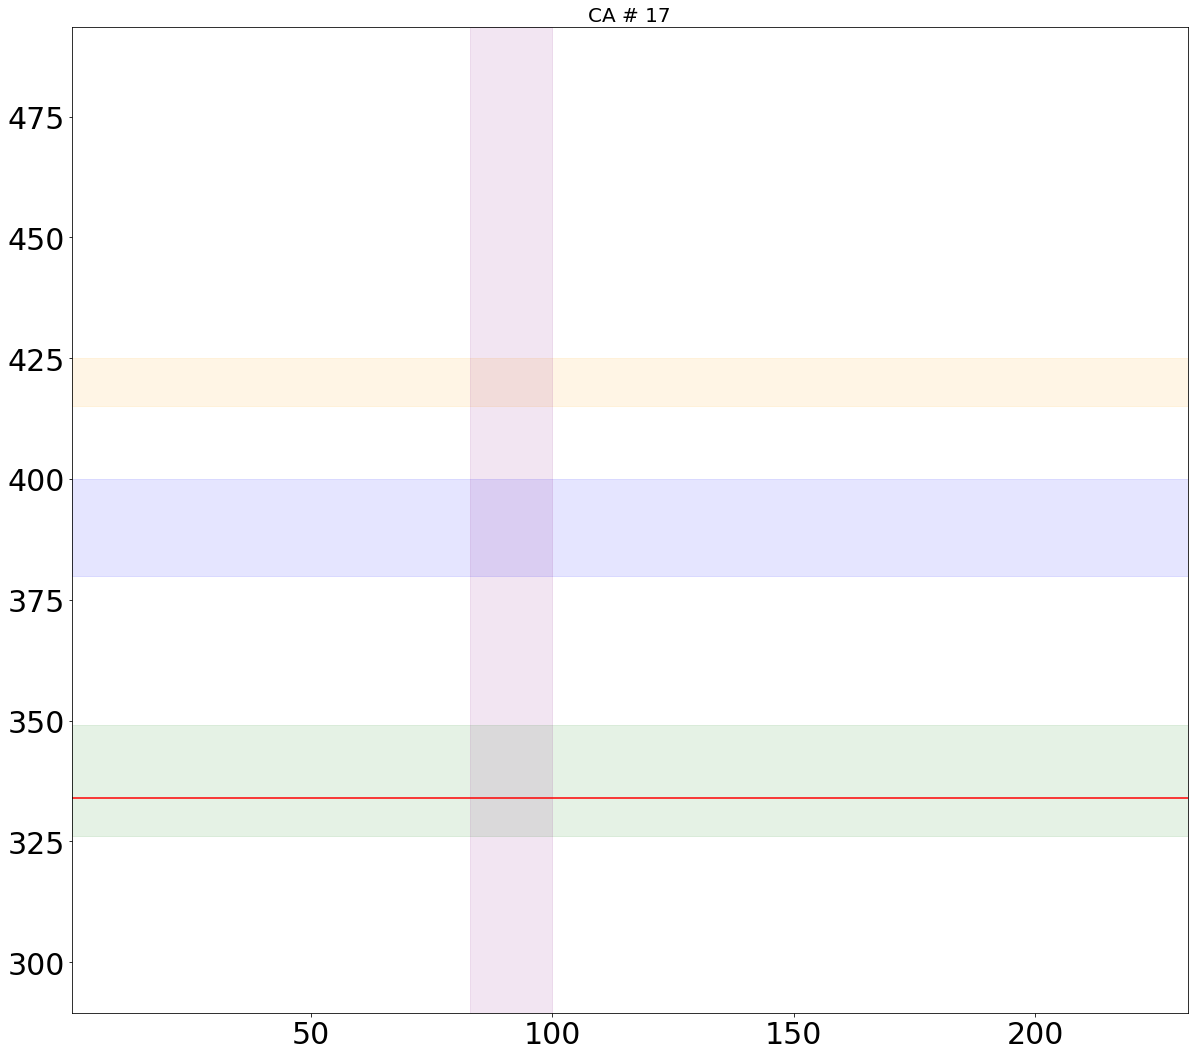

In [26]:
i=17
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")
axvspan(83,100,color = "purple",alpha = 0.1)


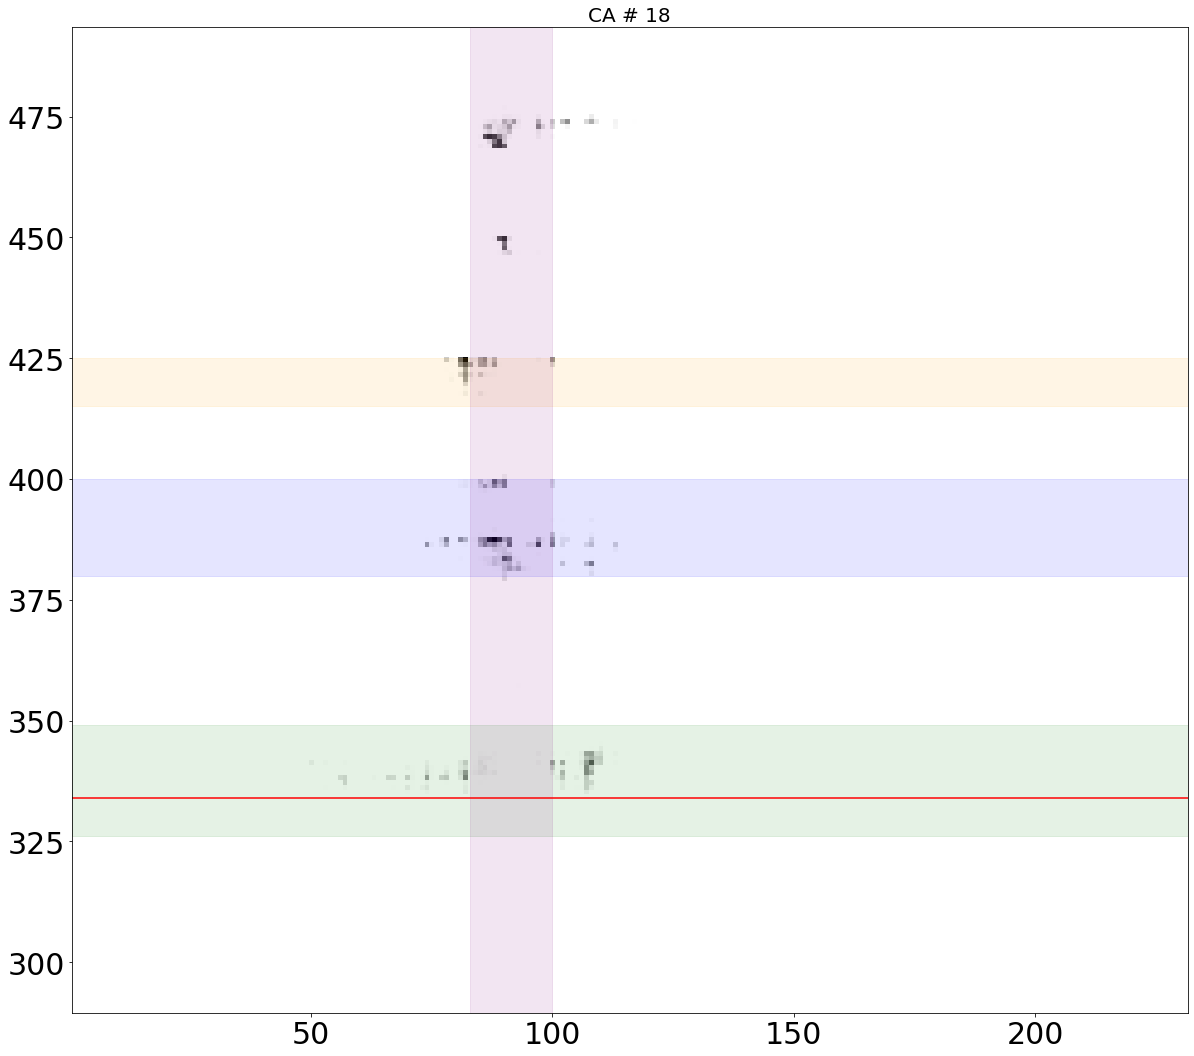

In [27]:


i=18
nspry = 493-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,1+nspry+(231*(i-1)):1+nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5,493.5))
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)


axhspan(326,349,color = "green",alpha = 0.1)
axhspan(380,400,color = "blue",alpha = 0.1)
axhspan(415,425,color = "orange",alpha = 0.1)


axhline(334,color = "red")

axvspan(83,100,color = "purple",alpha = 0.1)
